In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

## Data analysis

In [3]:
data = pd.read_csv("data/train.csv")

In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.isnull().sum

<bound method DataFrame.sum of      PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False 

In [6]:
survived = data['Survived'].sum()
not_survived = (data['Survived'] == 0).sum()
print(survived)
print(not_survived)

342
549


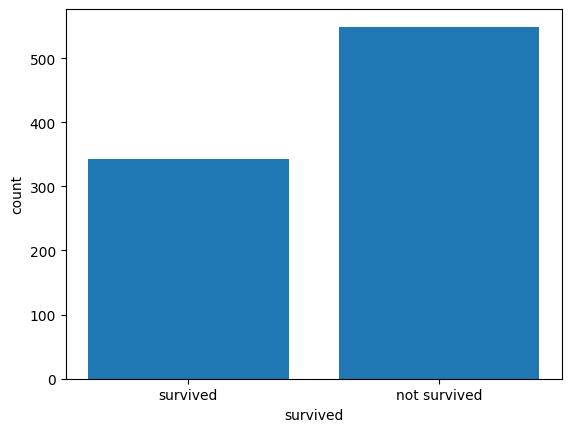

In [7]:
categories = ['survived', 'not survived']
values = [survived, not_survived]

plt.bar(categories, values)

plt.xlabel('survived')
plt.ylabel('count')

plt.show()

In [8]:
data.groupby(['Sex','Survived', 'Pclass'])['Survived'].count()

Sex     Survived  Pclass
female  0         1           3
                  2           6
                  3          72
        1         1          91
                  2          70
                  3          72
male    0         1          77
                  2          91
                  3         300
        1         1          45
                  2          17
                  3          47
Name: Survived, dtype: int64

In [9]:
pd.crosstab(index=data.Pclass, columns=[data.Survived,data.Sex],margins=True).style.background_gradient(axis=0)

In [10]:
data.groupby(['Pclass', 'Survived'])['Survived'].count()

Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

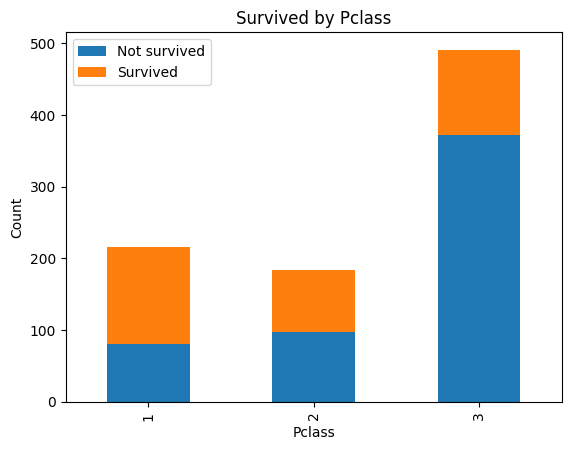

In [11]:
counts = data.groupby(['Pclass', 'Survived'])['Survived'].count().unstack(fill_value=0)

counts.plot(kind='bar', stacked=True)
plt.title('Survived by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.legend(['Not survived', 'Survived'])
plt.show()

In [12]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
/var/folders/0x/33gpdf5s7295nplw560g6d9w0000gn/T/ipykernel_55928/3164351286.py:3: SyntaxWarning: invalid escape sequence '\.'
  data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')


In [14]:
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)

/var/folders/0x/33gpdf5s7295nplw560g6d9w0000gn/T/ipykernel_55928/417967907.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)


In [15]:
data.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

In [16]:
data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age']=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age']=46

In [17]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.841942,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.281525,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,30.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
data['Embarked'].fillna('S',inplace=True)

/var/folders/0x/33gpdf5s7295nplw560g6d9w0000gn/T/ipykernel_55928/1306493021.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna('S',inplace=True)


In [19]:
data.Embarked.isnull().any()

np.False_

In [ ]:
pd.crosstab(index=data.SibSp, columns=data.Survived,margins=True).style.background_gradient(axis=0)

Survived,0,1,All
SibSp,,,
0,398,210,608
1,97,112,209
2,15,13,28
3,12,4,16
4,15,3,18
5,5,0,5
8,7,0,7
All,549,342,891


In [21]:
pd.crosstab(index=data.SibSp, columns=[data.Survived, data.Pclass],margins=True).style.background_gradient(axis=0)

In [22]:
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,2


In [23]:
data['Family_Size']=0
data['Family_Size']=data['Parch']+data['SibSp']
data['Alone']=0
data.loc[data.Family_Size==0,'Alone']=1

In [24]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_band,Family_Size,Alone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.841942,0.523008,0.381594,32.204208,1.439955,0.904602,0.602694
std,257.353842,0.486592,0.836071,13.281525,1.102743,0.806057,49.693429,0.842373,1.613459,0.489615
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,30.000000,0.000000,0.000000,14.454200,1.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000,2.000000,1.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,4.000000,10.000000,1.000000


In [25]:
data['Fare_Range']=pd.qcut(data['Fare'],4)

In [26]:
data['Fare_band']=0
data.loc[data['Fare']<=7.91,'Fare_band']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454),'Fare_band']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31),'Fare_band']=2
data.loc[(data['Fare']>31)&(data['Fare']<=513),'Fare_band']=3

In [27]:
data['Sex'].replace(['male','female'],[0,1],inplace=True)
data['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
data['Initial'].replace(['Mr','Mrs','Miss','Master','Other'],[0,1,2,3,4],inplace=True)

/var/folders/0x/33gpdf5s7295nplw560g6d9w0000gn/T/ipykernel_55928/3254487197.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sex'].replace(['male','female'],[0,1],inplace=True)
/var/folders/0x/33gpdf5s7295nplw560g6d9w0000gn/T/ipykernel_55928/3254487197.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasti

In [28]:
data.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'],axis=1,inplace=True)

In [ ]:
data

,Survived,Pclass,Sex,SibSp,Parch,Embarked,Initial,Age_band,Family_Size,Alone,Fare_band
0,0,3,0,1,0,0,0,1,1,0,0
1,1,1,1,1,0,1,1,2,1,0,3
2,1,3,1,0,0,0,2,1,0,1,1
3,1,1,1,1,0,0,1,2,1,0,3
4,0,3,0,0,0,0,0,2,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,0,0,0,4,1,0,1,1
887,1,1,1,0,0,0,2,1,0,1,2
888,0,3,1,1,2,0,2,1,3,0,2
889,1,1,0,0,0,1,0,1,0,1,2


## CV and Models

In [138]:
%pip install catboost scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /usr/local/bin/python3.13 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
data = pd.read_csv('data/train.csv')

In [53]:
X = data.drop(columns=["Survived"])
y = data["Survived"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [55]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [32]:
model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

F1 mean: 0.7422676111088545
Accuracy по фолдам: [0.77653631 0.80898876 0.78089888 0.82022472 0.84831461]
CV: 0.807
CV std: 0.0264
Precision mean: 0.7620946010506889
Recall mean: 0.7249360613810742


In [ ]:
model = LogisticRegression(max_iter=1000, penalty= 'l2')
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

F1 mean: 0.7422676111088545
Accuracy по фолдам: [0.77653631 0.80898876 0.78089888 0.82022472 0.84831461]
CV: 0.807
CV std: 0.0264
Precision mean: 0.7620946010506889
Recall mean: 0.7249360613810742


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

In [103]:
model = LogisticRegression(max_iter=1000,penalty='l1', solver='liblinear', C=1.0)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

F1 mean: 0.7405286130024976
Accuracy по фолдам: [0.78212291 0.80337079 0.78651685 0.82022472 0.84269663]
CV: 0.807
CV std: 0.0224
Precision mean: 0.7646090575371867
Recall mean: 0.7190963341858483


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

In [105]:
model = LogisticRegression(max_iter=1000,penalty='elasticnet', solver='saga')
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

F1 mean: 0.7422676111088545
Accuracy по фолдам: [0.77653631 0.80898876 0.78089888 0.82022472 0.84831461]
CV: 0.807
CV std: 0.0264
Precision mean: 0.7620946010506889
Recall mean: 0.7249360613810742


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
model = KNeighborsClassifier(n_neighbors=14)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

F1 mean: 0.7385440264541255
Accuracy по фолдам: [0.82681564 0.81460674 0.79775281 0.83146067 0.81460674]
CV: 0.817
CV std: 0.0117
Precision mean: 0.8168559031542928
Recall mean: 0.6753196930946291


In [122]:
model = KNeighborsClassifier(n_neighbors=14, weights='distance')
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

F1 mean: 0.7535119768575651
Accuracy по фолдам: [0.79888268 0.80898876 0.82022472 0.83146067 0.8258427 ]
CV: 0.8171
CV std: 0.0117
Precision mean: 0.7813523383814067
Recall mean: 0.728005115089514


In [ ]:
model = KNeighborsClassifier(n_neighbors=14, weights='distance')
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

In [121]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

F1 mean: 0.7719677722373919
Accuracy по фолдам: [0.83240223 0.82022472 0.83146067 0.83146067 0.85393258]
CV: 0.8339
CV std: 0.011
Precision mean: 0.8152705896254282
Recall mean: 0.7337595907928389


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42, verbose=2)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91 of 100
building tree 92 of 100
building tree 93 of 100
building tree 94 of 100
building tree 95 of 100
building tree 96 of 100
building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91 of 100
building tree 92 of 100
building tree 93 of 100
building tree 94

...

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


In [35]:
import catboost
from catboost import CatBoostClassifier

In [36]:
model =CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss', 
    verbose=10, 
    random_seed=42
)
model.fit(X, y)


0:	learn: 0.6565416	total: 57.8ms	remaining: 5.72s
10:	learn: 0.4764544	total: 59.6ms	remaining: 482ms
20:	learn: 0.4194685	total: 61.5ms	remaining: 231ms
30:	learn: 0.3986266	total: 63.1ms	remaining: 140ms
40:	learn: 0.3854057	total: 64.6ms	remaining: 92.9ms
50:	learn: 0.3762629	total: 66.2ms	remaining: 63.6ms
60:	learn: 0.3699795	total: 67.7ms	remaining: 43.3ms
70:	learn: 0.3649308	total: 69.2ms	remaining: 28.3ms
80:	learn: 0.3593976	total: 70.8ms	remaining: 16.6ms
90:	learn: 0.3541458	total: 72.3ms	remaining: 7.15ms
99:	learn: 0.3507432	total: 73.6ms	remaining: 0us


In [ ]:
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

0:	learn: 0.6549051	total: 1.1ms	remaining: 109ms
10:	learn: 0.4741775	total: 3.24ms	remaining: 26.2ms
20:	learn: 0.4243537	total: 5.02ms	remaining: 18.9ms
30:	learn: 0.4022794	total: 7.1ms	remaining: 15.8ms
40:	learn: 0.3900568	total: 8.63ms	remaining: 12.4ms
50:	learn: 0.3810843	total: 12.6ms	remaining: 12.1ms
60:	learn: 0.3738539	total: 15.2ms	remaining: 9.74ms
70:	learn: 0.3686884	total: 16.7ms	remaining: 6.82ms
80:	learn: 0.3649216	total: 18ms	remaining: 4.23ms
90:	learn: 0.3612895	total: 19.4ms	remaining: 1.92ms
99:	learn: 0.3577914	total: 20.6ms	remaining: 0us
0:	learn: 0.6581514	total: 161us	remaining: 16ms
10:	learn: 0.4781953	total: 1.37ms	remaining: 11.1ms
20:	learn: 0.4211759	total: 2.63ms	remaining: 9.89ms
30:	learn: 0.3996212	total: 4.17ms	remaining: 9.27ms
40:	learn: 0.3870121	total: 5.61ms	remaining: 8.08ms
50:	learn: 0.3778702	total: 7ms	remaining: 6.72ms
60:	learn: 0.3697125	total: 8.09ms	remaining: 5.17ms
70:	learn: 0.3629156	total: 9.18ms	remaining: 3.75ms
80:	learn

In [39]:
import lightgbm as lgb

In [46]:
model = lgb.LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.03)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 47
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
%pip install xgboost

In [51]:
import xgboost as xgb
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, objective='binary:logistic',eval_metric="logloss", random_state=42)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

Precision mean: 0.7976364764267989
Recall mean: 0.7250213128729752
F1 mean: 0.7589488268008375
Accuracy по фолдам: [0.82122905 0.8258427  0.80337079 0.83146067 0.83707865]
CV: 0.8238
CV std: 0.0115


## DNN

In [33]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=2, max_iter=100, activation='relu', solver='adam', random_state=1)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iteration

Precision mean: 0.7461870406153782
Recall mean: 0.6196504688832054
F1 mean: 0.6750408809916333
Accuracy по фолдам: [0.76536313 0.75842697 0.76966292 0.78089888 0.78651685]
CV: 0.7722
CV std: 0.0102


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iteration

In [46]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=210, max_iter=100, activation='relu', solver='adam', random_state=1)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")

precision = cross_val_score(model, X, y, cv=skf, scoring="precision")
recall = cross_val_score(model, X, y, cv=skf, scoring="recall")

print("Precision mean:", precision.mean())
print("Recall mean:", recall.mean())

print("F1 mean:", f1.mean())
print("Accuracy по фолдам:", scores)

print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iteration

Precision mean: 0.8070248386886305
Recall mean: 0.7162830349531117
F1 mean: 0.7583132719770604
Accuracy по фолдам: [0.83240223 0.81460674 0.83707865 0.81460674 0.8258427 ]
CV: 0.8249
CV std: 0.0091


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [42]:
%pip install tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (4.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached h5py-3.15.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (3.0 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-macosx_10_13_universal2.whl.metadata (8.9 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.18.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (34 kB)
Using cached tensorflow-2.20.0-cp31

In [49]:
model.fit(X, y)
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi.head(20))


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


In [ ]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=14)),
        ('rf',  RandomForestClassifier(n_estimators=500, random_state=42)),
        ('lr',  LogisticRegression(C=0.05, max_iter=2000)),
        ('dt',  DecisionTreeClassifier(random_state=42)),
    ],
    voting='hard'
)
scores = cross_val_score(ensemble, X, y, cv=skf, scoring="accuracy")
print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))
print("Folds:", scores)

CV: 0.8227
CV std: 0.0084
Folds: [0.82122905 0.8258427  0.81460674 0.83707865 0.81460674]


In [ ]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=14)),
        ('rf',  RandomForestClassifier(n_estimators=500, random_state=42)),
        ('lr',  LogisticRegression(C=0.05, max_iter=2000)),
        ('dt',  DecisionTreeClassifier(random_state=42)),
    ],
    voting='soft',
    weights=[0.2, 0.4, 0.3, 0.1]
)
scores = cross_val_score(ensemble, X, y, cv=skf, scoring="accuracy")
print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))
print("Folds:", scores)

CV: 0.8182
CV std: 0.0126
Folds: [0.81564246 0.79775281 0.82022472 0.83707865 0.82022472]


In [66]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier

base_estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=14)),
        ('rf',  RandomForestClassifier(n_estimators=500, random_state=42)),
        ('lr',  LogisticRegression(C=0.05, max_iter=2000)),
        ('dt',  DecisionTreeClassifier(random_state=42)),
    
]
stack_ridge = StackingClassifier(
    estimators=base_estimators,
    final_estimator= RidgeClassifier(),
    stack_method='predict',
    passthrough=False
)
scores = cross_val_score(stack_ridge, X, y, cv=skf, scoring="accuracy")
print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))
print("Folds:", scores)

CV: 0.8171
CV std: 0.0166
Folds: [0.82122905 0.82022472 0.78651685 0.83707865 0.82022472]


In [67]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier

base_estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=14)),
        ('rf',  RandomForestClassifier(n_estimators=500, random_state=42)),
        ('lr',  LogisticRegression(C=0.05, max_iter=2000)),
        ('dt',  DecisionTreeClassifier(random_state=42)),
    
]
stack_ridge = StackingClassifier(
    estimators=base_estimators,
    final_estimator= RidgeClassifier(),
    stack_method='auto',
    passthrough=False
)
scores = cross_val_score(stack_ridge, X, y, cv=skf, scoring="accuracy")
print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))
print("Folds:", scores)

CV: 0.8104
CV std: 0.0182
Folds: [0.78212291 0.79775281 0.81460674 0.83146067 0.8258427 ]


In [ ]:
from sklearn.ensemble import StackingClassifier

base_estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=14)),
        ('rf',  RandomForestClassifier(n_estimators=500, random_state=42)),
        ('lr',  LogisticRegression(C=0.05, max_iter=2000)),
        ('dt',  DecisionTreeClassifier(random_state=42)),
    
]
stack_ridge = StackingClassifier(
    estimators=base_estimators,
    stack_method='predict_proba',
    passthrough=False
)
scores = cross_val_score(stack_ridge, X, y, cv=skf, scoring="accuracy")
print("CV:", round(scores.mean(),4))
print("CV std:", round(scores.std(),4))
print("Folds:", scores)

CV: 0.8137
CV std: 0.0208
Folds: [0.78212291 0.79775281 0.82022472 0.83146067 0.83707865]
